# Thompson Sampling — Reddit DSTC8 Corpus

In this notebook we train a **fixed** Thompson Sampling contextual bandit on a customer service environment
modeled after the **Reddit DSTC8 Corpus** characteristics.

Reddit threads are **longer and more neutral** — users are less frustrated but conversations
take more turns to resolve. Info gathering is slower.

### Key Fixes Applied
1. **3D state discretization**: sentiment × frustration × `info_gathered` (64 contexts instead of 16)
2. **Threshold-based reward normalization**: positive reward = success, else failure
3. **Reduced step penalty**: −0.02 instead of −0.1 (especially important for Reddit's 20 max turns)

### Metrics We Track
| Metric | What It Tells |
|---|---|
| **Average Reward** | Overall agent performance per episode — higher is better |
| **Resolution Rate** | % of conversations where the issue was solved |
| **Escalation Rate** | % of conversations handed off to a human (agent gave up) |
| **Avg Turns** | How long conversations take on average |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
import sys
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from environment import CustomerServiceEnv

print('all imports done!')

all imports done!


## Setting up the Environment

In [2]:
env = CustomerServiceEnv(dataset='reddit')

print(f'Environment: {env.dataset_name}')
print(f'Max turns per conversation: {env.max_turns}')
print(f'Initial sentiment: {env.initial_sentiment} (0=angry, 1=happy)')
print(f'Initial frustration: {env.initial_frustration}')
print(f'Available actions: {env.ACTIONS}')
print(f'State vector size: {env.get_state_size()} [sentiment, frustration, info_gathered, turn_progress]')

Environment: Reddit DSTC8 Corpus
Max turns per conversation: 20
Initial sentiment: 0.5 (0=angry, 1=happy)
Initial frustration: 0.3
Available actions: ['ask_info', 'provide_solution', 'empathize', 'escalate', 'close']
State vector size: 4 [sentiment, frustration, info_gathered, turn_progress]


## Running a random episode

In [3]:
state = env.reset()
total_reward = 0
print('--- Random Agent Episode ---')
print(f'Starting state: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
print()

while not env.done:
    action = random.randint(0, env.NUM_ACTIONS - 1)
    next_state, reward, done, outcome = env.step(action)
    total_reward += reward
    env.render(action)
    state = next_state

print(f'\nTotal reward: {total_reward:.2f}')
print(f'Conversation ended: {outcome}')

--- Random Agent Episode ---
Starting state: sentiment=0.50, frustration=0.32

  Turn  1 | Action: empathize
    Sentiment: 0.62 | Frustration: 0.22 | Info: 0.00
  Turn  2 | Action: close
    Sentiment: 0.62 | Frustration: 0.22 | Info: 0.00
    >> Outcome: abandoned

Total reward: -1.84
Conversation ended: abandoned


## Thompson Sampling Agent (Fixed)

In [4]:
class ThompsonSamplingAgent:
    
    def __init__(self, n_actions=5, n_bins=4):
        self.n_actions = n_actions
        self.n_bins = n_bins
        self.n_contexts = n_bins * n_bins * n_bins
        self.alpha = np.ones((self.n_contexts, n_actions))
        self.beta_param = np.ones((self.n_contexts, n_actions))
    
    def _get_context(self, state):
        """discretize sentiment, frustration, AND info_gathered into a context id"""
        sent_bin = min(int(state[0] * self.n_bins), self.n_bins - 1)
        frust_bin = min(int(state[1] * self.n_bins), self.n_bins - 1)
        info_bin = min(int(state[2] * self.n_bins), self.n_bins - 1)
        return (sent_bin * self.n_bins + frust_bin) * self.n_bins + info_bin
    
    def choose_action(self, state):
        ctx = self._get_context(state)
        samples = np.random.beta(self.alpha[ctx], self.beta_param[ctx])
        return np.argmax(samples)
    
    def update(self, state, action, reward):
        """threshold-based update: positive reward = success, else failure"""
        ctx = self._get_context(state)
        if reward > 0:
            self.alpha[ctx, action] += 1
        else:
            self.beta_param[ctx, action] += 1

print(f'Thompson Sampling agent defined!')
print(f'State space: 4x4x4 = 64 contexts x 5 actions = 320 pairs')

Thompson Sampling agent defined!
State space: 4x4x4 = 64 contexts x 5 actions = 320 pairs


## Training

In [5]:
agent = ThompsonSamplingAgent(n_actions=env.NUM_ACTIONS, n_bins=4)
num_episodes = 20000

all_rewards = []
all_outcomes = []
all_turns = []

for ep in range(num_episodes):
    state = env.reset()
    episode_reward = 0
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        agent.update(state, action, reward)
        episode_reward += reward
        state = next_state
    
    all_rewards.append(episode_reward)
    all_outcomes.append(outcome)
    all_turns.append(env.turn)
    
    if (ep + 1) % 4000 == 0:
        recent_rewards = all_rewards[-500:]
        recent_resolved = sum(1 for o in all_outcomes[-500:] if o == 'resolved') / 500
        recent_escalated = sum(1 for o in all_outcomes[-500:] if o == 'escalated') / 500
        print(f'Episode {ep+1}/{num_episodes}')
        print(f'  Avg reward (last 500): {np.mean(recent_rewards):.2f}')
        print(f'  Resolution rate: {recent_resolved:.1%}')
        print(f'  Escalation rate: {recent_escalated:.1%}')
        print(f'  Avg turns: {np.mean(all_turns[-500:]):.1f}')
        print()

print('Training complete!')

Episode 4000/20000
  Avg reward (last 500): 3.05
  Resolution rate: 99.6%
  Escalation rate: 0.2%
  Avg turns: 10.2

Episode 8000/20000
  Avg reward (last 500): 3.07
  Resolution rate: 99.8%
  Escalation rate: 0.0%
  Avg turns: 10.3

Episode 12000/20000
  Avg reward (last 500): 3.07
  Resolution rate: 99.8%
  Escalation rate: 0.0%
  Avg turns: 10.3

Episode 16000/20000
  Avg reward (last 500): 3.09
  Resolution rate: 100.0%
  Escalation rate: 0.0%
  Avg turns: 10.4

Episode 20000/20000
  Avg reward (last 500): 3.10
  Resolution rate: 100.0%
  Escalation rate: 0.0%
  Avg turns: 10.4

Training complete!


## Learning Curve

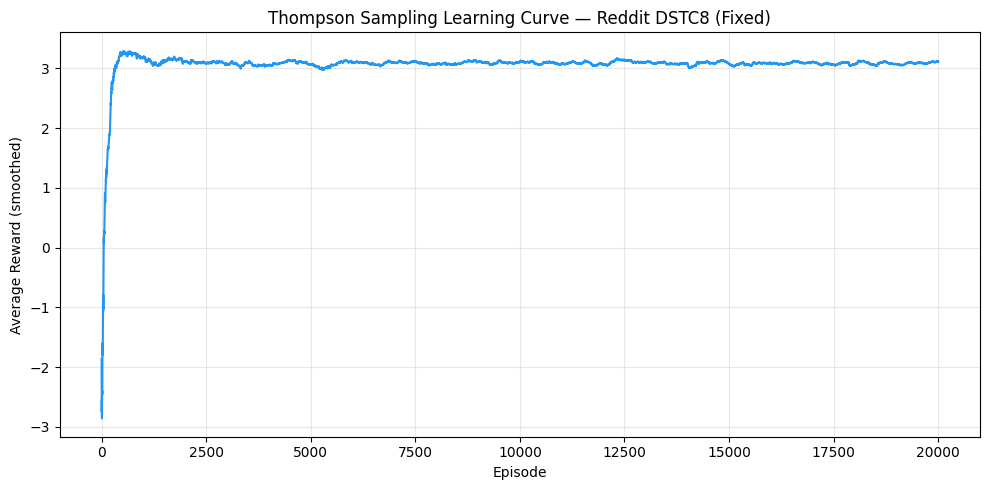

Starting avg reward (first 500): 2.68
Final avg reward (last 500): 3.10


In [6]:
window = 200
smoothed = [np.mean(all_rewards[max(0,i-window):i+1]) for i in range(len(all_rewards))]

plt.figure(figsize=(10, 5))
plt.plot(smoothed, color='#2196F3', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Average Reward (smoothed)')
plt.title('Thompson Sampling Learning Curve — Reddit DSTC8 (Fixed)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Starting avg reward (first 500): {np.mean(all_rewards[:500]):.2f}')
print(f'Final avg reward (last 500): {np.mean(all_rewards[-500:]):.2f}')

## Resolution Rate Over Time

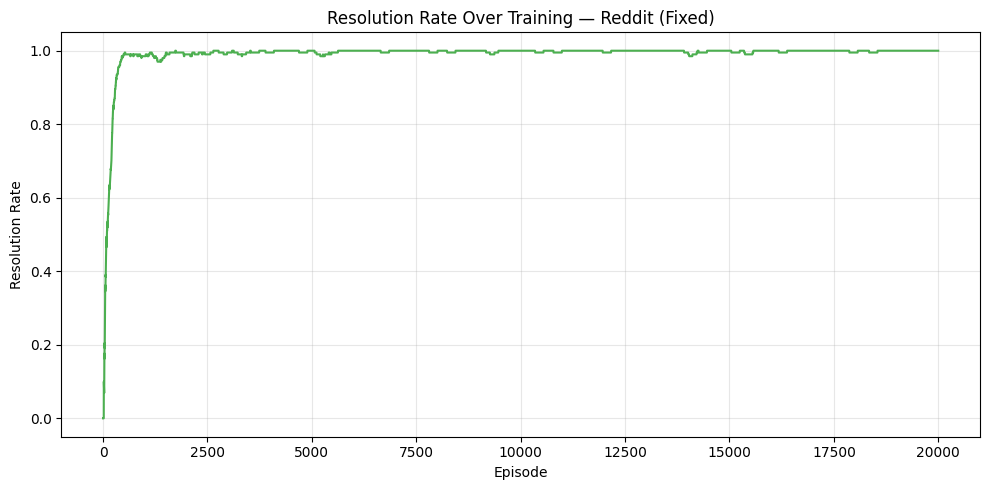

In [7]:
resolution_window = 200
resolution_rates = []
for i in range(len(all_outcomes)):
    start = max(0, i - resolution_window)
    window_outcomes = all_outcomes[start:i+1]
    rate = sum(1 for o in window_outcomes if o == 'resolved') / len(window_outcomes)
    resolution_rates.append(rate)

plt.figure(figsize=(10, 5))
plt.plot(resolution_rates, color='#4CAF50', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Resolution Rate')
plt.title('Resolution Rate Over Training — Reddit (Fixed)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What Actions did the Agent Learn?

In [8]:
test_scenarios = [
    {'name': 'Angry customer, no info', 'state': [0.2, 0.8, 0.1, 0.1]},
    {'name': 'Calm customer, no info', 'state': [0.7, 0.2, 0.1, 0.1]},
    {'name': 'Angry customer, lots of info', 'state': [0.2, 0.8, 0.8, 0.3]},
    {'name': 'Calm customer, lots of info', 'state': [0.7, 0.2, 0.8, 0.3]},
    {'name': 'Neutral, halfway through', 'state': [0.5, 0.5, 0.5, 0.5]},
]

print('What the agent would do in different situations:')
print('=' * 60)
for scenario in test_scenarios:
    state = np.array(scenario['state'])
    action_counts = np.zeros(env.NUM_ACTIONS)
    for _ in range(1000):
        a = agent.choose_action(state)
        action_counts[a] += 1
    action_counts /= 1000
    
    print(f"\n{scenario['name']}:")
    for i, action_name in enumerate(env.ACTIONS):
        bar = '#' * int(action_counts[i] * 40)
        print(f'  {action_name:18s} {action_counts[i]:.1%} {bar}')

What the agent would do in different situations:

Angry customer, no info:
  ask_info           22.7% #########
  provide_solution   25.4% ##########
  empathize          23.5% #########
  escalate           5.7% ##
  close              22.7% #########

Calm customer, no info:
  ask_info           38.2% ###############
  provide_solution   0.0% 
  empathize          61.8% ########################
  escalate           0.0% 
  close              0.0% 

Angry customer, lots of info:
  ask_info           25.5% ##########
  provide_solution   36.4% ##############
  empathize          24.7% #########
  escalate           1.7% 
  close              11.7% ####

Calm customer, lots of info:
  ask_info           55.6% ######################
  provide_solution   0.0% 
  empathize          5.2% ##
  escalate           0.0% 
  close              39.2% ###############

Neutral, halfway through:
  ask_info           54.6% #####################
  provide_solution   0.0% 
  empathize          45.4% ###

## Action Distribution Plot

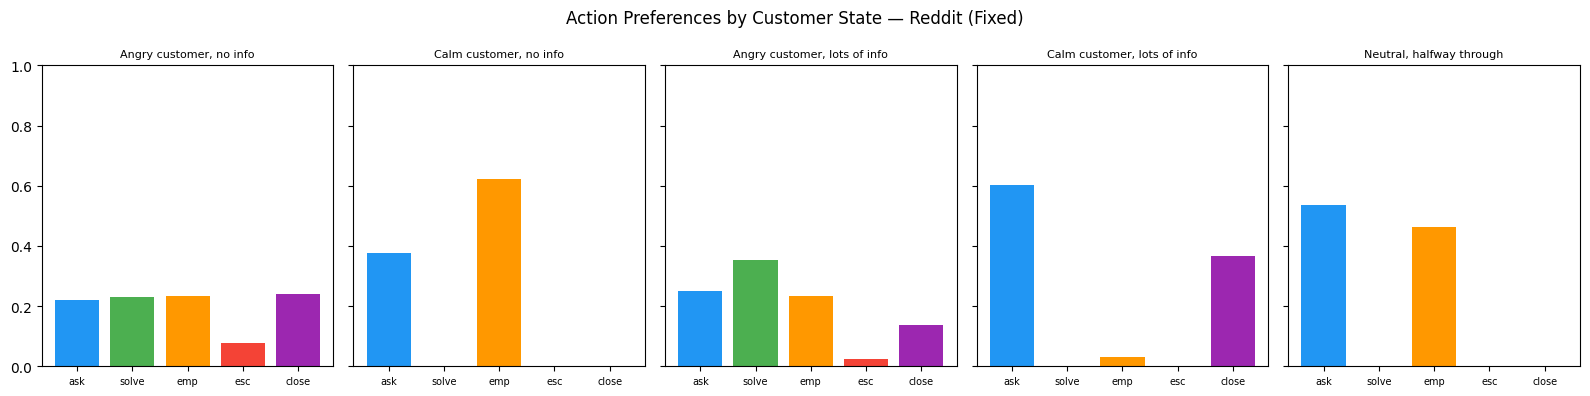

In [9]:
fig, axes = plt.subplots(1, len(test_scenarios), figsize=(16, 4), sharey=True)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#f44336', '#9C27B0']

for idx, scenario in enumerate(test_scenarios):
    state = np.array(scenario['state'])
    action_counts = np.zeros(env.NUM_ACTIONS)
    for _ in range(1000):
        a = agent.choose_action(state)
        action_counts[a] += 1
    action_counts /= 1000
    
    axes[idx].bar(range(env.NUM_ACTIONS), action_counts, color=colors)
    axes[idx].set_title(scenario['name'], fontsize=8)
    axes[idx].set_xticks(range(env.NUM_ACTIONS))
    axes[idx].set_xticklabels(['ask', 'solve', 'emp', 'esc', 'close'], fontsize=7)
    axes[idx].set_ylim(0, 1)

fig.suptitle('Action Preferences by Customer State — Reddit (Fixed)', fontsize=12)
plt.tight_layout()
plt.show()

## Testing the Trained Agent

In [10]:
print('='*60)
print('TESTING THE TRAINED AGENT — 3 sample conversations')
print('='*60)

for test_ep in range(3):
    state = env.reset()
    total_reward = 0
    print(f'\n--- Conversation {test_ep+1} ---')
    print(f'Customer arrives: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        total_reward += reward
        action_name = env.ACTIONS[action]
        print(f'  Turn {env.turn}: Agent chose [{action_name}] -> reward={reward:.2f}, sentiment={next_state[0]:.2f}, info={next_state[2]:.2f}')
        state = next_state
    
    print(f'  Result: {outcome} | Total reward: {total_reward:.2f} | Turns: {env.turn}')

TESTING THE TRAINED AGENT — 3 sample conversations

--- Conversation 1 ---
Customer arrives: sentiment=0.53, frustration=0.32
  Turn 1: Agent chose [ask_info] -> reward=0.08, sentiment=0.53, info=0.09
  Turn 2: Agent chose [empathize] -> reward=0.18, sentiment=0.65, info=0.09
  Turn 3: Agent chose [ask_info] -> reward=0.08, sentiment=0.65, info=0.20
  Turn 4: Agent chose [ask_info] -> reward=0.08, sentiment=0.62, info=0.36
  Turn 5: Agent chose [ask_info] -> reward=0.08, sentiment=0.59, info=0.57
  Turn 6: Agent chose [empathize] -> reward=0.18, sentiment=0.71, info=0.57
  Turn 7: Agent chose [empathize] -> reward=0.18, sentiment=0.83, info=0.57
  Turn 8: Agent chose [ask_info] -> reward=0.08, sentiment=0.80, info=0.69
  Turn 9: Agent chose [ask_info] -> reward=0.08, sentiment=0.77, info=0.79
  Turn 10: Agent chose [close] -> reward=1.98, sentiment=0.77, info=0.79
  Result: resolved | Total reward: 3.00 | Turns: 10

--- Conversation 2 ---
Customer arrives: sentiment=0.55, frustration=0

## Final Summary Stats

In [11]:
test_rewards = []
test_outcomes = {'resolved': 0, 'escalated': 0, 'abandoned': 0}
test_turns = []

for _ in range(500):
    state = env.reset()
    ep_reward = 0
    while not env.done:
        action = agent.choose_action(state)
        state, reward, done, outcome = env.step(action)
        ep_reward += reward
    test_rewards.append(ep_reward)
    test_outcomes[outcome] += 1
    test_turns.append(env.turn)

print('='*50)
print('FINAL EVALUATION (500 test episodes)')
print('='*50)
print(f'Average reward:     {np.mean(test_rewards):.2f}')
print(f'Resolution rate:    {test_outcomes["resolved"]/500:.1%}')
print(f'Escalation rate:    {test_outcomes["escalated"]/500:.1%}')
print(f'Abandonment rate:   {test_outcomes["abandoned"]/500:.1%}')
print(f'Avg conversation:   {np.mean(test_turns):.1f} turns')
print('='*50)

FINAL EVALUATION (500 test episodes)
Average reward:     3.08
Resolution rate:    100.0%
Escalation rate:    0.0%
Abandonment rate:   0.0%
Avg conversation:   10.4 turns


## Observations

*TODO: Write your observations here after running the notebook.*